Data loaded successfully from: data/cleaned_data.csv

--- 1. Age Category Correlation ---


C:\Users\jsrri\AppData\Local\Temp\ipykernel_7544\268707346.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


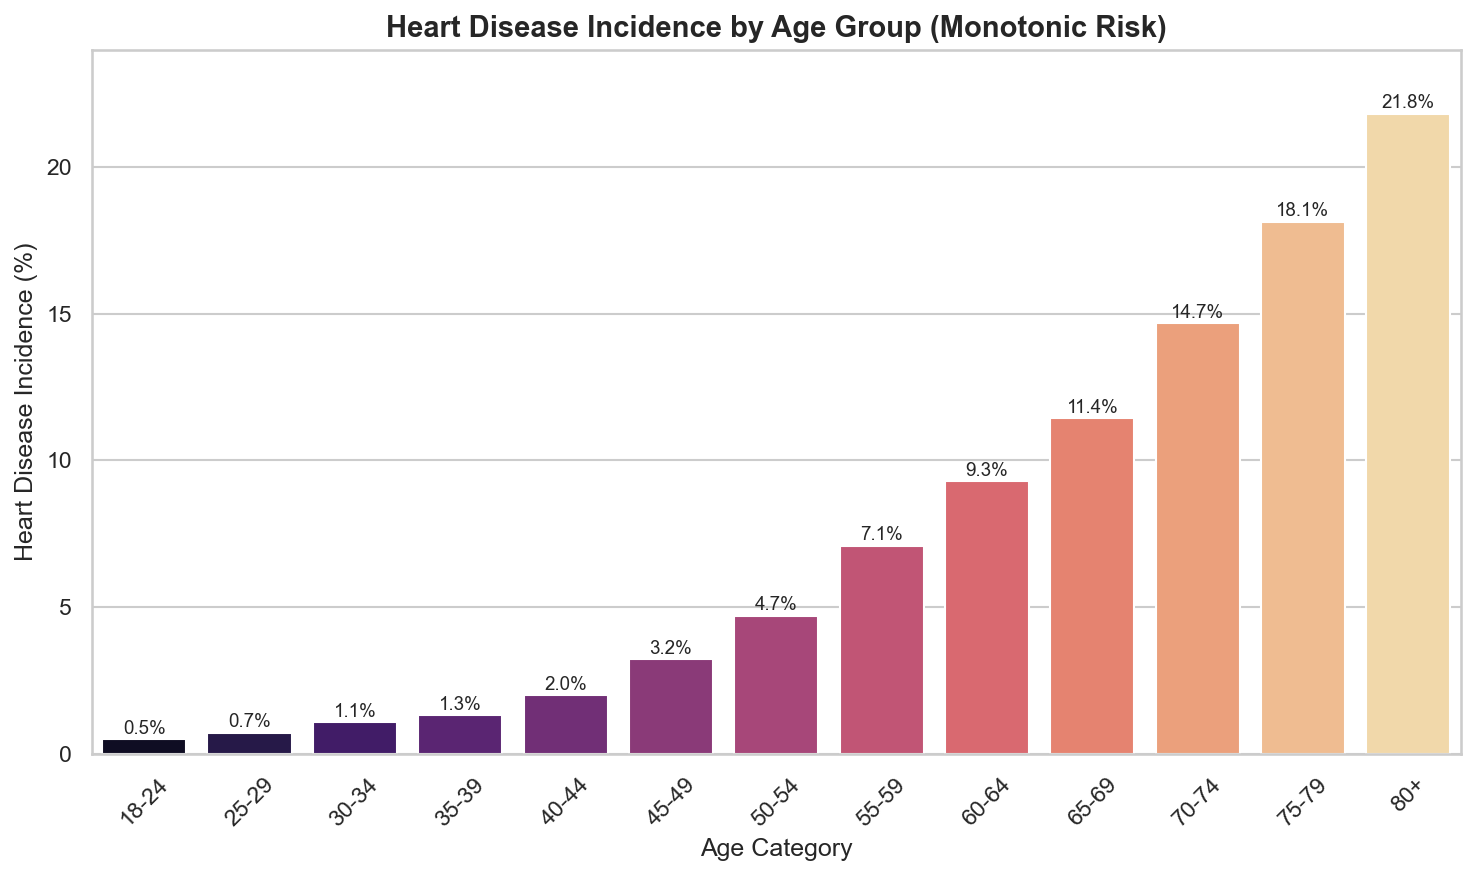


--- 2. General Health Correlation ---


C:\Users\jsrri\AppData\Local\Temp\ipykernel_7544\268707346.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


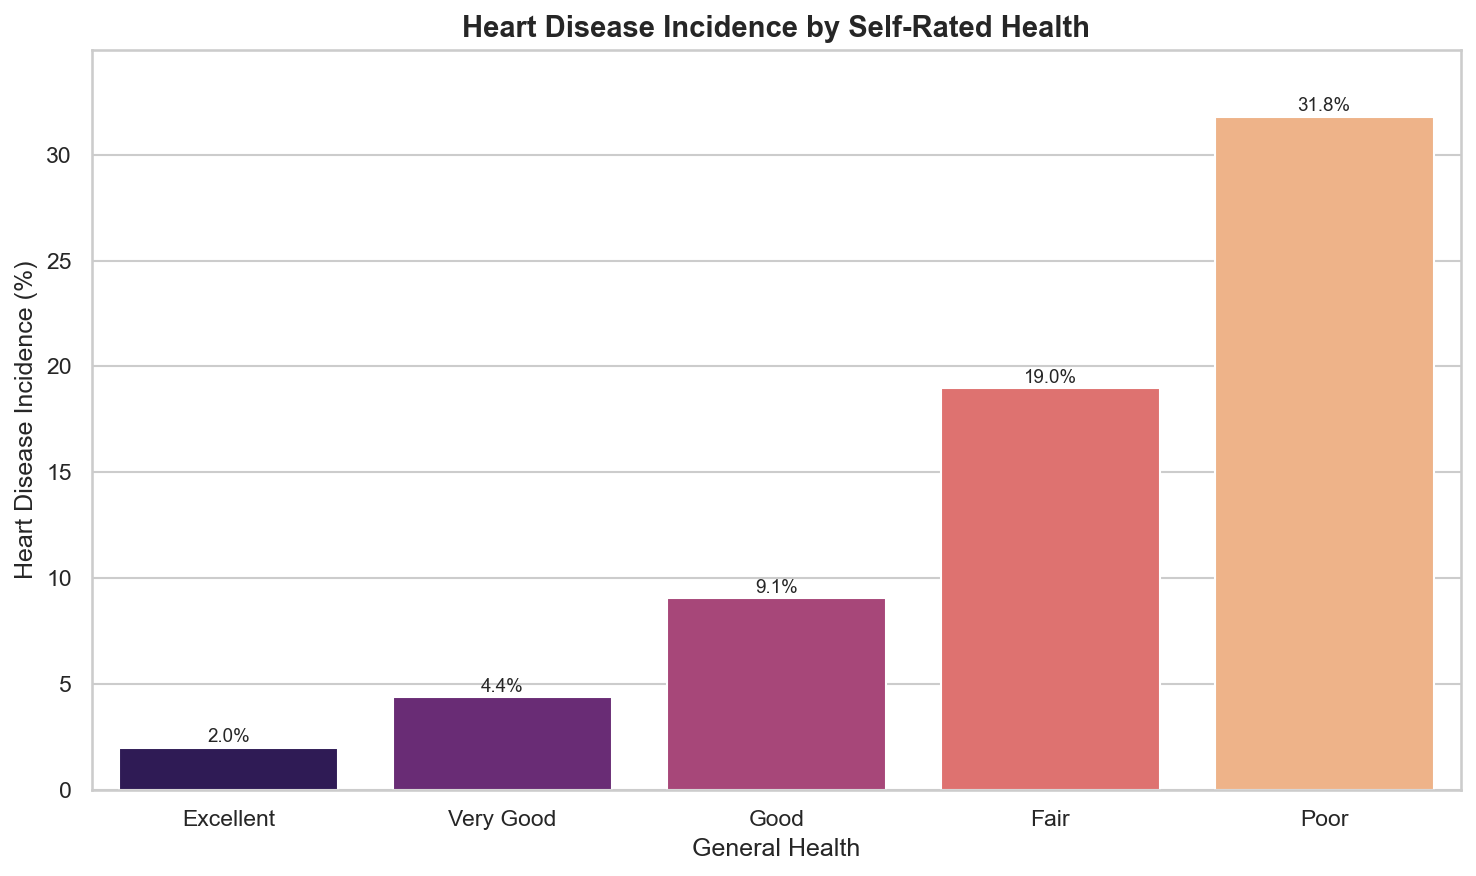


--- 3. Comorbidity Stacking ---


<Figure size 1500x900 with 0 Axes>

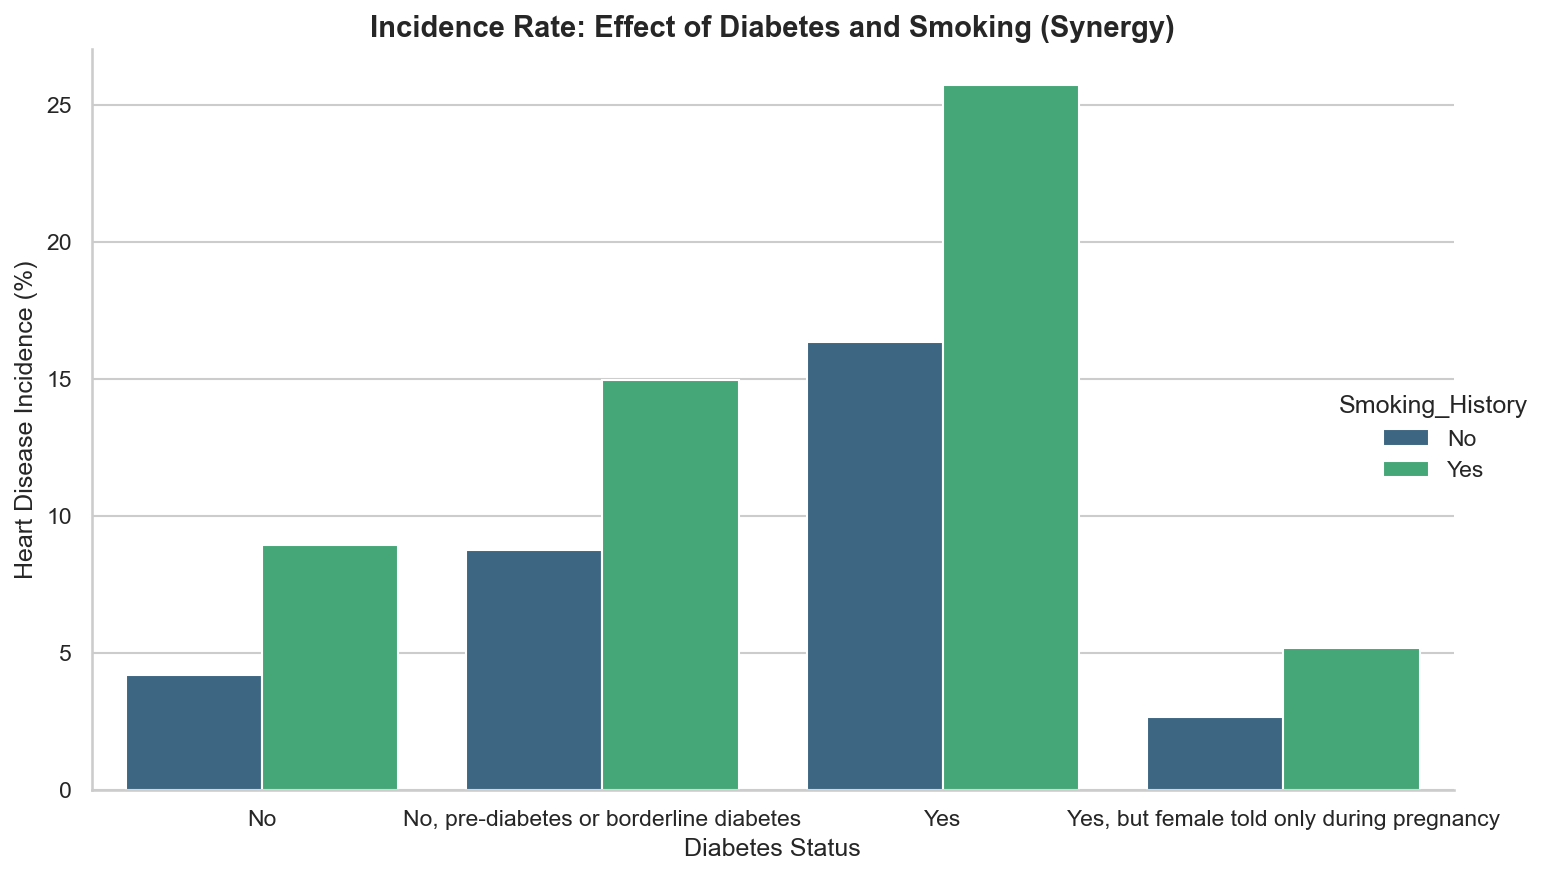

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- Configuration ---
# Set path to your cleaned data (adjust if needed)
DATA_PATH = 'data/cleaned_data.csv'
# Set global style for better visualization
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = (10, 6)

def calculate_incidence_rate(df, group_col, target_col='Heart_Disease'):
    """Calculates the percentage of 'Yes' outcomes for each category."""
    
    # Convert target to numeric (1 for Yes, 0 for No)
    df_temp = df.copy()
    df_temp[target_col] = df_temp[target_col].map({'Yes': 1, 'No': 0})
    
    # Calculate mean (which is the incidence rate)
    incidence = df_temp.groupby(group_col)[target_col].mean().reset_index()
    incidence[target_col] = incidence[target_col] * 100 # Convert to percentage
    
    return incidence

def plot_incidence(data, x_col, title, order=None, rotation=0):
    """Generates a bar plot for incidence rates."""
    plt.figure()
    
    ax = sns.barplot(
        x=x_col, 
        y='Heart_Disease', 
        data=data, 
        order=order,
        palette='magma'
    )
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel('Heart Disease Incidence (%)', fontsize=12)
    plt.xlabel(x_col.replace('_', ' '), fontsize=12)
    plt.xticks(rotation=rotation)
    plt.ylim(0, max(data['Heart_Disease']) * 1.1)
    
    # Add values on top of bars
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 5), 
                    textcoords = 'offset points',
                    fontsize=9)
    
    plt.tight_layout()
    # 

# --- Main EDA Visualization ---
try:
    df = pd.read_csv(DATA_PATH)
    print(f"Data loaded successfully from: {DATA_PATH}")
    
    # --- 1. Age Category Correlation (Strongest Predictor) ---
    print("\n--- 1. Age Category Correlation ---")
    age_incidence = calculate_incidence_rate(df, 'Age_Category')
    # Order by age group to show monotonic increase
    age_order = sorted(df['Age_Category'].unique(), 
                       key=lambda x: int(x.split('-')[0]) if '-' in x else int(x.strip('+')))
                       
    plot_incidence(age_incidence, 
                   'Age_Category', 
                   'Heart Disease Incidence by Age Group (Monotonic Risk)', 
                   order=age_order, 
                   rotation=45)
    plt.show()

    # --- 2. General Health Correlation (The Ordinal Feature Signal) ---
    print("\n--- 2. General Health Correlation ---")
    health_incidence = calculate_incidence_rate(df, 'General_Health')
    # Order health from best to worst to show monotonic increase
    health_order = ['Excellent', 'Very Good', 'Good', 'Fair', 'Poor']
    
    plot_incidence(health_incidence, 
                   'General_Health', 
                   'Heart Disease Incidence by Self-Rated Health', 
                   order=health_order)
    plt.show()
    
    # --- 3. Comorbidity Stacking (The Hidden Synergistic Signal) ---
    print("\n--- 3. Comorbidity Stacking ---")
    # Group by Diabetes status and then Smoking History
    comorbidity_incidence = df.groupby(['Diabetes', 'Smoking_History'])['Heart_Disease'].value_counts(normalize=True).mul(100).rename('percent').reset_index()
    comorbidity_incidence = comorbidity_incidence[comorbidity_incidence['Heart_Disease'] == 'Yes']

    plt.figure()
    sns.catplot(
        data=comorbidity_incidence, 
        x='Diabetes', 
        y='percent', 
        hue='Smoking_History', 
        kind='bar',
        palette='viridis',
        height=6, 
        aspect=1.5
    )
    plt.title('Incidence Rate: Effect of Diabetes and Smoking (Synergy)', fontsize=14, fontweight='bold')
    plt.ylabel('Heart Disease Incidence (%)', fontsize=12)
    plt.xlabel('Diabetes Status', fontsize=12)
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"\nError: Data file not found at {DATA_PATH}. Please check your path.")
except Exception as e:
    print(f"\nAn unexpected error occurred during plotting: {e}")


Age Correlation (Monotonic Increase): We see a smooth, steep ramp-up in the incidence rate from the youngest to the oldest age categories. This is the single strongest predictor of the target variable.

General Health Correlation (Ordinal Signal): We see a clear, inverse relationship: the incidence rate for people reporting "Poor" health is dramatically higher than for those reporting "Excellent" health. This relationship justifies the use of these features, which we considered changing to OHE (though OHE might still be better, this plot confirms the inherent signal).

Comorbidity Stacking: The plot showing Diabetes and Smoking demonstrate synergy. We see:

Lowest risk: Yes, but female told only during pregnancy, No Smoking.

Moderate risk: Diabetes (No, pre-diabetes or borderline diabetes), Smoking (Yes) or Diabetes (Yes), Smoking (No).

Highest risk: Diabetes (Yes) and Smoking (Yes).

The relationships are not simple linear correlations but clear conditional probabilities and monotonic relationships, which tree-based models (CatBoost, XGBoost) are perfectly designed to exploit.


Data loaded successfully from: data/cleaned_data.csv

--- 1. BMI Incidence by Clinical Category ---


C:\Users\jsrri\AppData\Local\Temp\ipykernel_7544\2105976306.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


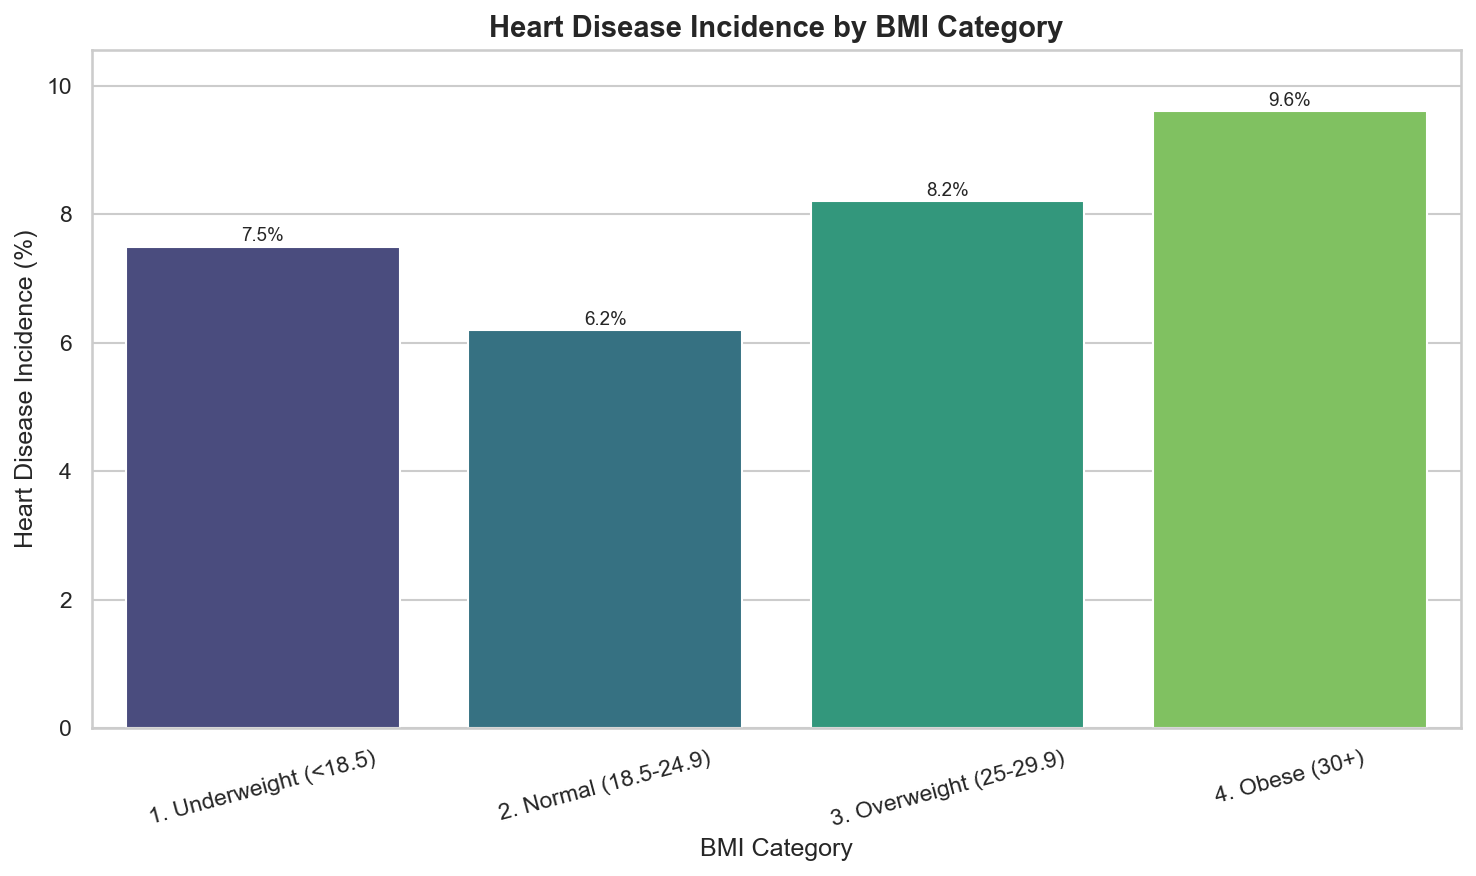


--- 2. Exercise Incidence ---


C:\Users\jsrri\AppData\Local\Temp\ipykernel_7544\2105976306.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


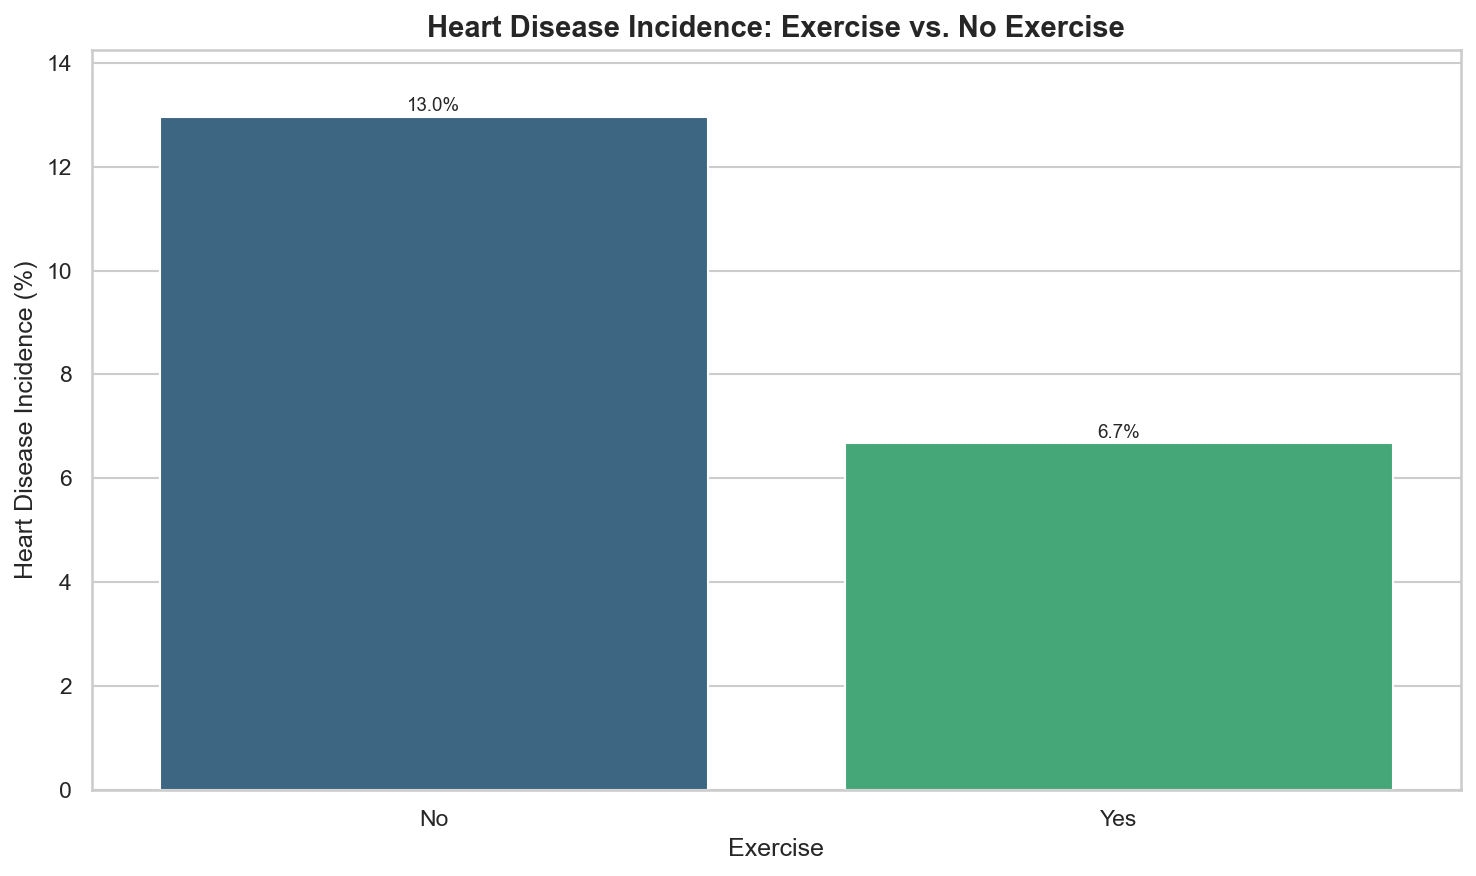


--- 3. Chronic Condition Synergy (Arthritis & Depression) ---


C:\Users\jsrri\AppData\Local\Temp\ipykernel_7544\2105976306.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


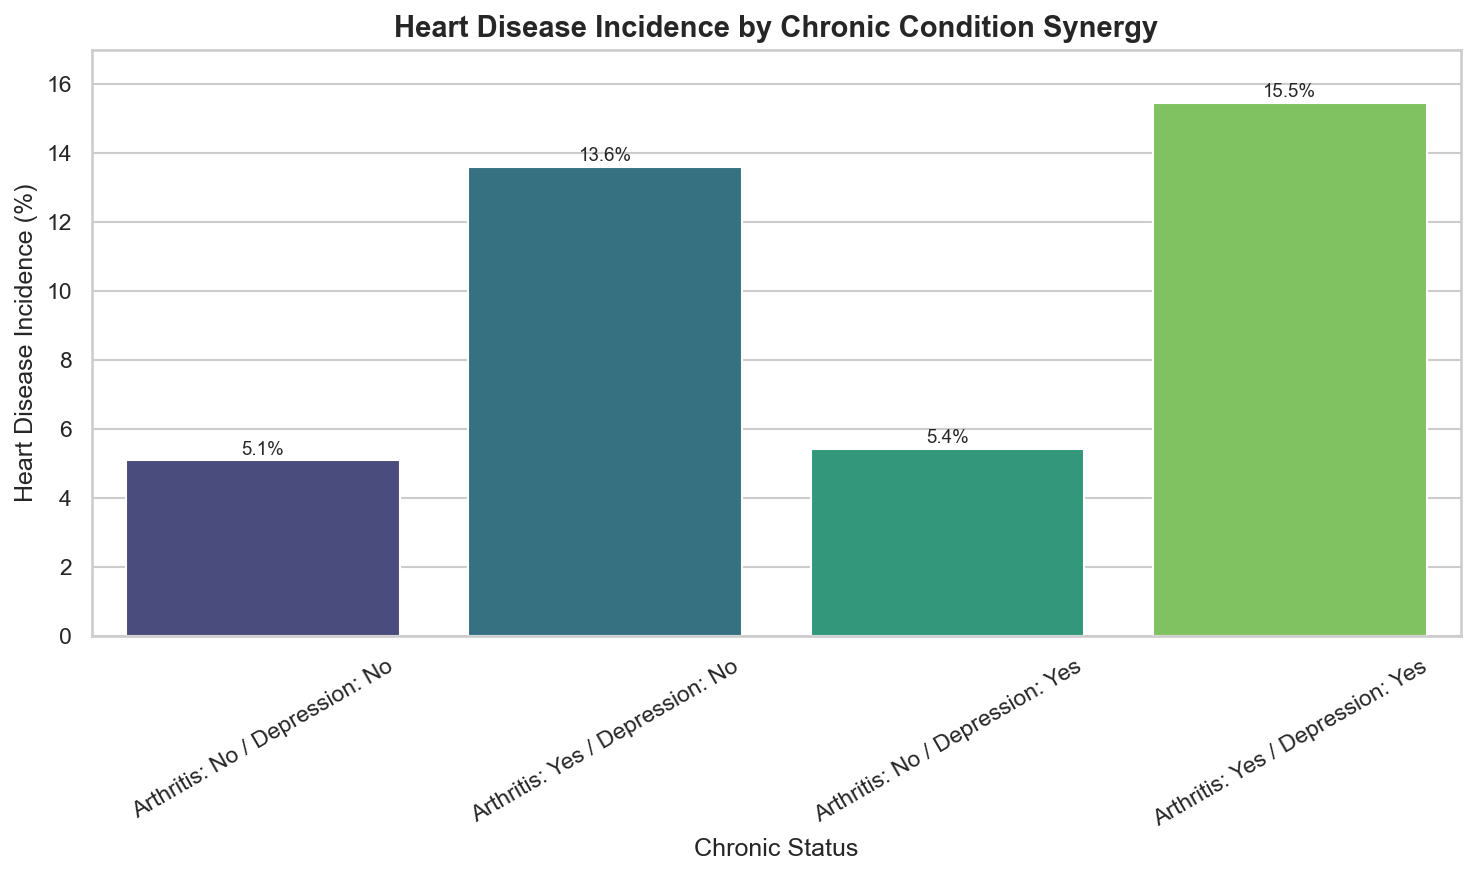

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- Configuration ---
# Set path to your cleaned data (adjust if needed)
DATA_PATH = 'data/cleaned_data.csv'
# Set global style for better visualization
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = (10, 6)

def calculate_incidence_rate(df, group_col, target_col='Heart_Disease'):
    """Calculates the percentage of 'Yes' outcomes for each category."""
    
    # Convert target to numeric (1 for Yes, 0 for No)
    df_temp = df.copy()
    df_temp[target_col] = df_temp[target_col].map({'Yes': 1, 'No': 0})
    
    # Calculate mean (which is the incidence rate)
    incidence = df_temp.groupby(group_col)[target_col].mean().reset_index()
    incidence[target_col] = incidence[target_col] * 100 # Convert to percentage
    
    return incidence

def plot_incidence(data, x_col, title, order=None, rotation=0, aspect=1.5):
    """Generates a bar plot for incidence rates."""
    plt.figure()
    
    ax = sns.barplot(
        x=x_col, 
        y='Heart_Disease', 
        data=data, 
        order=order,
        palette='viridis' # Changed palette for diversity
    )
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel('Heart Disease Incidence (%)', fontsize=12)
    plt.xlabel(x_col.replace('_', ' '), fontsize=12)
    plt.xticks(rotation=rotation)
    plt.ylim(0, max(data['Heart_Disease']) * 1.1)
    
    # Add values on top of bars
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 5), 
                    textcoords = 'offset points',
                    fontsize=9)
    
    plt.tight_layout()
    # 


def create_bmi_categories(bmi):
    """Bins BMI into standard clinical categories."""
    if bmi < 18.5:
        return '1. Underweight (<18.5)'
    elif bmi < 25:
        return '2. Normal (18.5-24.9)'
    elif bmi < 30:
        return '3. Overweight (25-29.9)'
    else:
        return '4. Obese (30+)'


# --- Main EDA Visualization ---
try:
    df = pd.read_csv(DATA_PATH)
    print(f"Data loaded successfully from: {DATA_PATH}")
    
    # ---------------------------------------------
    # 1. BMI (Numerical Feature Binned)
    # ---------------------------------------------
    print("\n--- 1. BMI Incidence by Clinical Category ---")
    
    # Create the BMI category column
    df['BMI_Category'] = df['BMI'].apply(create_bmi_categories)
    
    bmi_incidence = calculate_incidence_rate(df, 'BMI_Category')
    
    plot_incidence(
        bmi_incidence, 
        'BMI_Category', 
        'Heart Disease Incidence by BMI Category', 
        order=sorted(df['BMI_Category'].unique()), 
        rotation=15
    )
    plt.show()

    # ---------------------------------------------
    # 2. Exercise (Binary Feature)
    # ---------------------------------------------
    print("\n--- 2. Exercise Incidence ---")

    exercise_incidence = calculate_incidence_rate(df, 'Exercise')
    
    plot_incidence(
        exercise_incidence, 
        'Exercise', 
        'Heart Disease Incidence: Exercise vs. No Exercise', 
        order=['No', 'Yes']
    )
    plt.show()

    # ---------------------------------------------
    # 3. Comorbidity Synergy (Arthritis and Depression)
    # ---------------------------------------------
    print("\n--- 3. Chronic Condition Synergy (Arthritis & Depression) ---")
    
    # Combine Arthritis and Depression into a single categorical feature for easier plotting
    df['Chronic_Status'] = df.apply(
        lambda row: f"Arthritis: {row['Arthritis']} / Depression: {row['Depression']}", axis=1
    )
    
    chronic_incidence = calculate_incidence_rate(df, 'Chronic_Status')
    
    # Sort order to show increasing risk
    chronic_order = [
        'Arthritis: No / Depression: No',
        'Arthritis: Yes / Depression: No',
        'Arthritis: No / Depression: Yes',
        'Arthritis: Yes / Depression: Yes',
    ]
    
    plot_incidence(
        chronic_incidence, 
        'Chronic_Status', 
        'Heart Disease Incidence by Chronic Condition Synergy', 
        order=chronic_order, 
        rotation=30
    )
    plt.show()


except FileNotFoundError:
    print(f"\nError: Data file not found at {DATA_PATH}. Please check your path.")
except Exception as e:
    print(f"\nAn unexpected error occurred during plotting: {e}")


BMI (The Log Transformation Justification): We see the incidence rate start low (Normal Weight) and then accelerate sharply in the Overweight and Obese categories. This non-linear spike justifies why you included the BMI_log feature—it helps the model capture the accelerating risk at higher BMI values much better than the raw, linearly scaled BMI. Interestingly underweight people are at 1.3 % higher risk comared to normal weight people.

Exercise: We see that people who answer "No" to exercise have a noticeably higher incidence rate than those who answer "Yes." This confirms the protective effect of exercise is captured in the data.

Chronic Synergy: The most interesting plot is the synergy plot. We see the highest incidence rate for the group with both Arthritis and Depression. This confirms that the presence of multiple chronic inflammatory conditions significantly compounds the risk, and the model must learn this stacking effect.

These visualizations give us full confidence in the signal strength of the features we selected for our final model.

Attempting to load data from (Absolute Path): C:\Users\jsrri\FSD\Integration-project-Masoud\HeartDiseasePredictorProject\heart-disease-predictor\backend\notebook\data\cleaned_data.csv
Data loaded successfully from: data/cleaned_data.csv
Plots will be saved to the directory (Absolute Path): C:\Users\jsrri\FSD\Integration-project-Masoud\HeartDiseasePredictorProject\heart-disease-predictor\backend\notebook\eda_plots

--- 1. BMI Incidence by Clinical Category ---


C:\Users\jsrri\AppData\Local\Temp\ipykernel_14652\4229508054.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


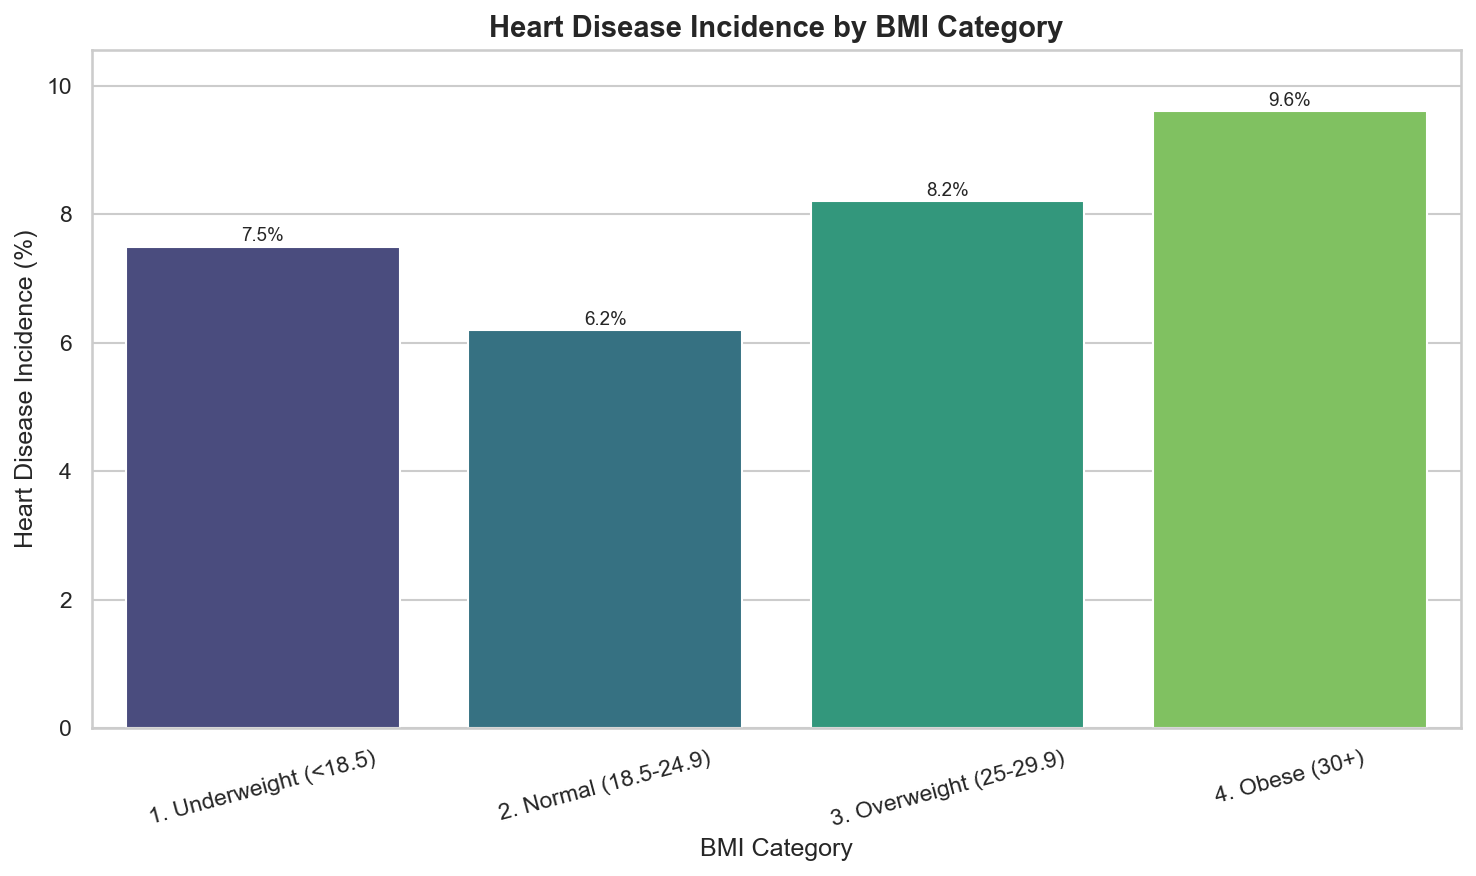


--- 2. Exercise Incidence ---


C:\Users\jsrri\AppData\Local\Temp\ipykernel_14652\4229508054.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


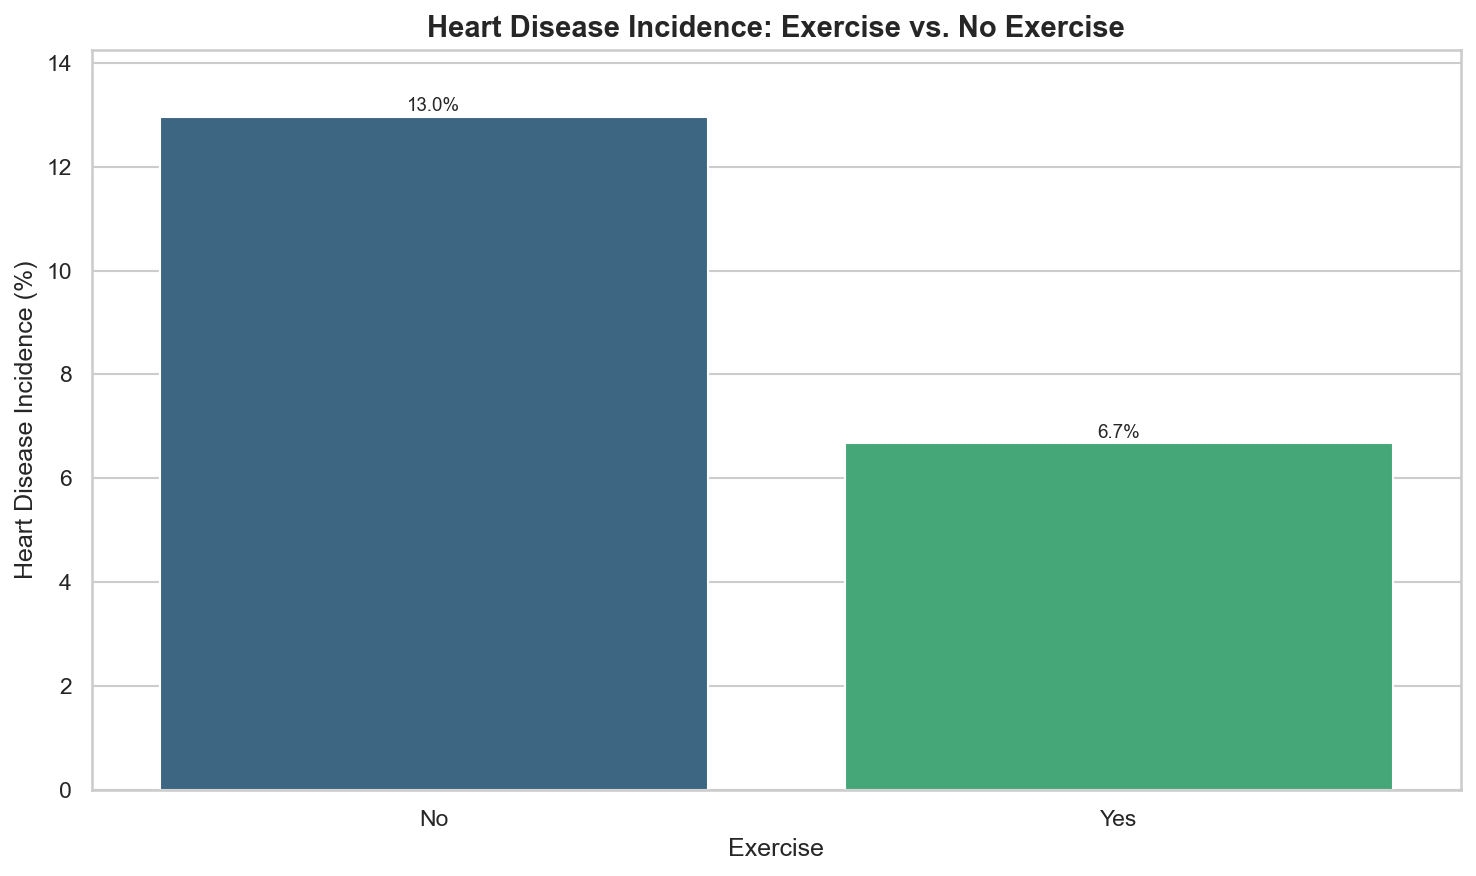


--- 3. Chronic Condition Synergy (Arthritis & Depression) ---


C:\Users\jsrri\AppData\Local\Temp\ipykernel_14652\4229508054.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


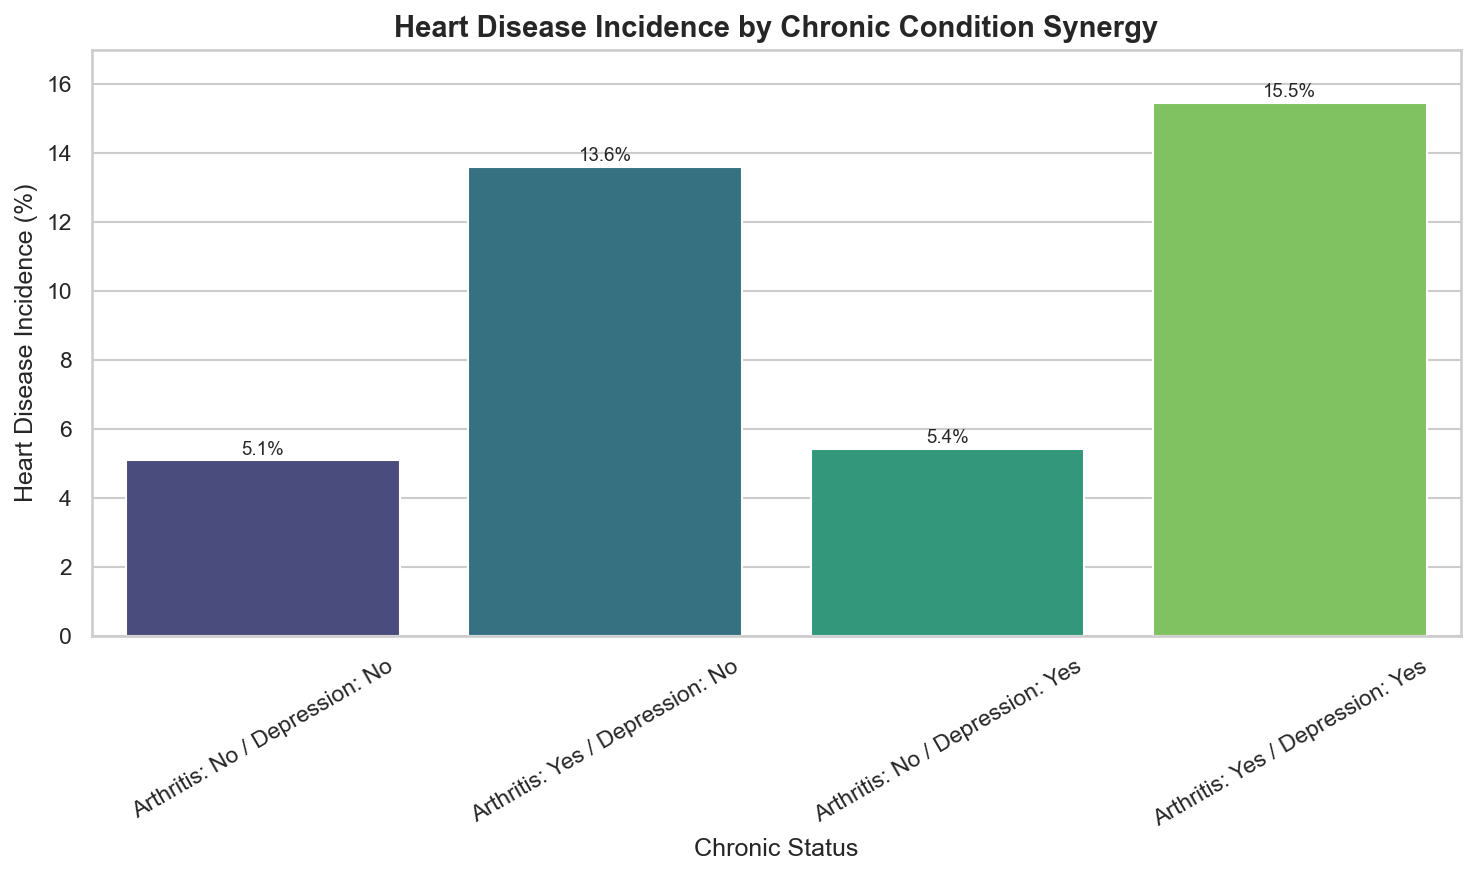


--- 4. Checkup Status Incidence ---


C:\Users\jsrri\AppData\Local\Temp\ipykernel_14652\4229508054.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


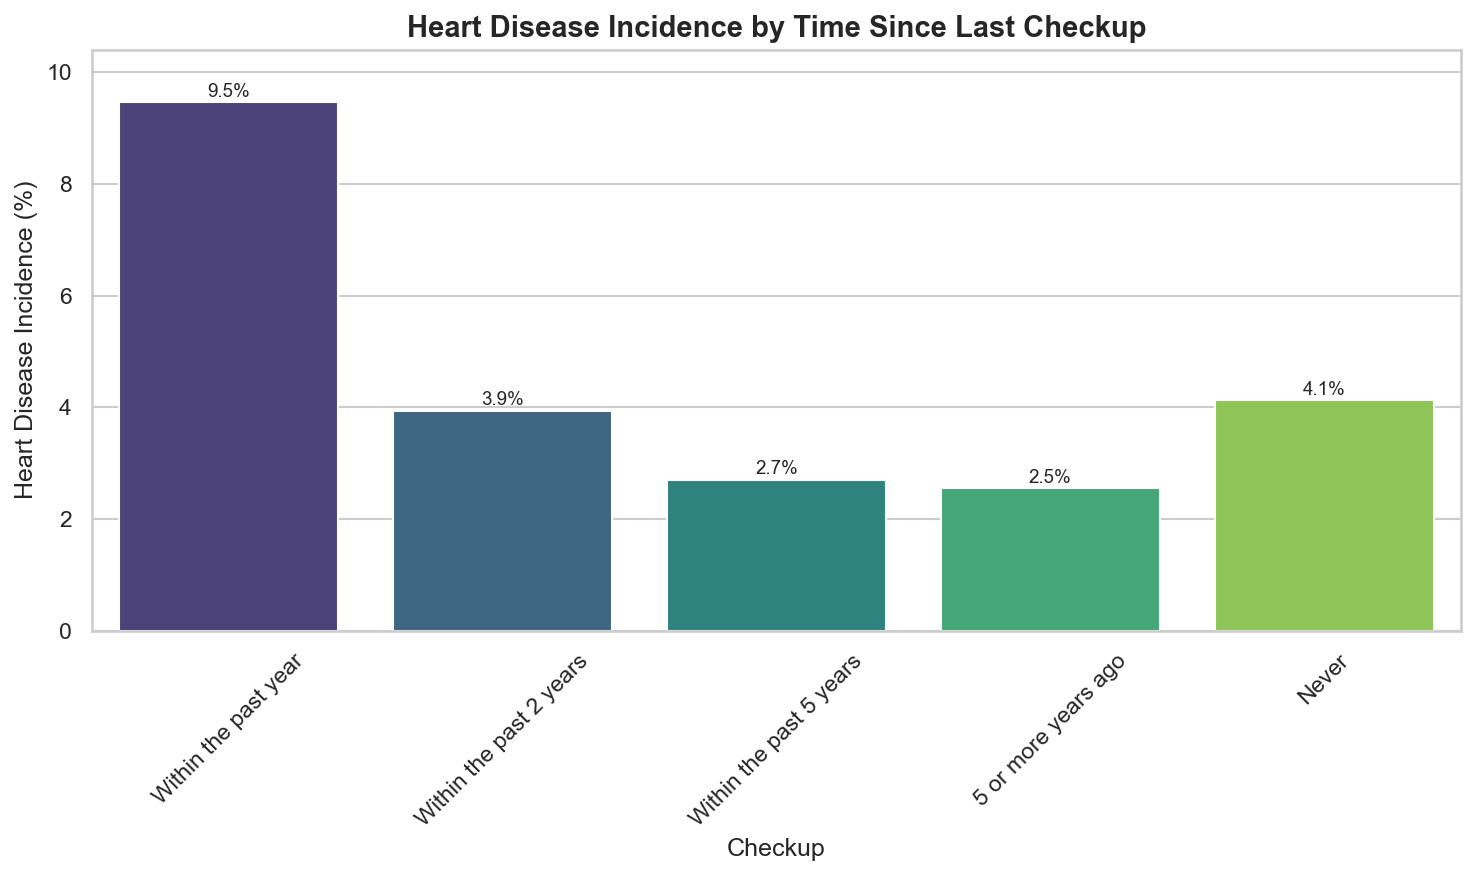


--- 5. Sex Incidence ---


C:\Users\jsrri\AppData\Local\Temp\ipykernel_14652\4229508054.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


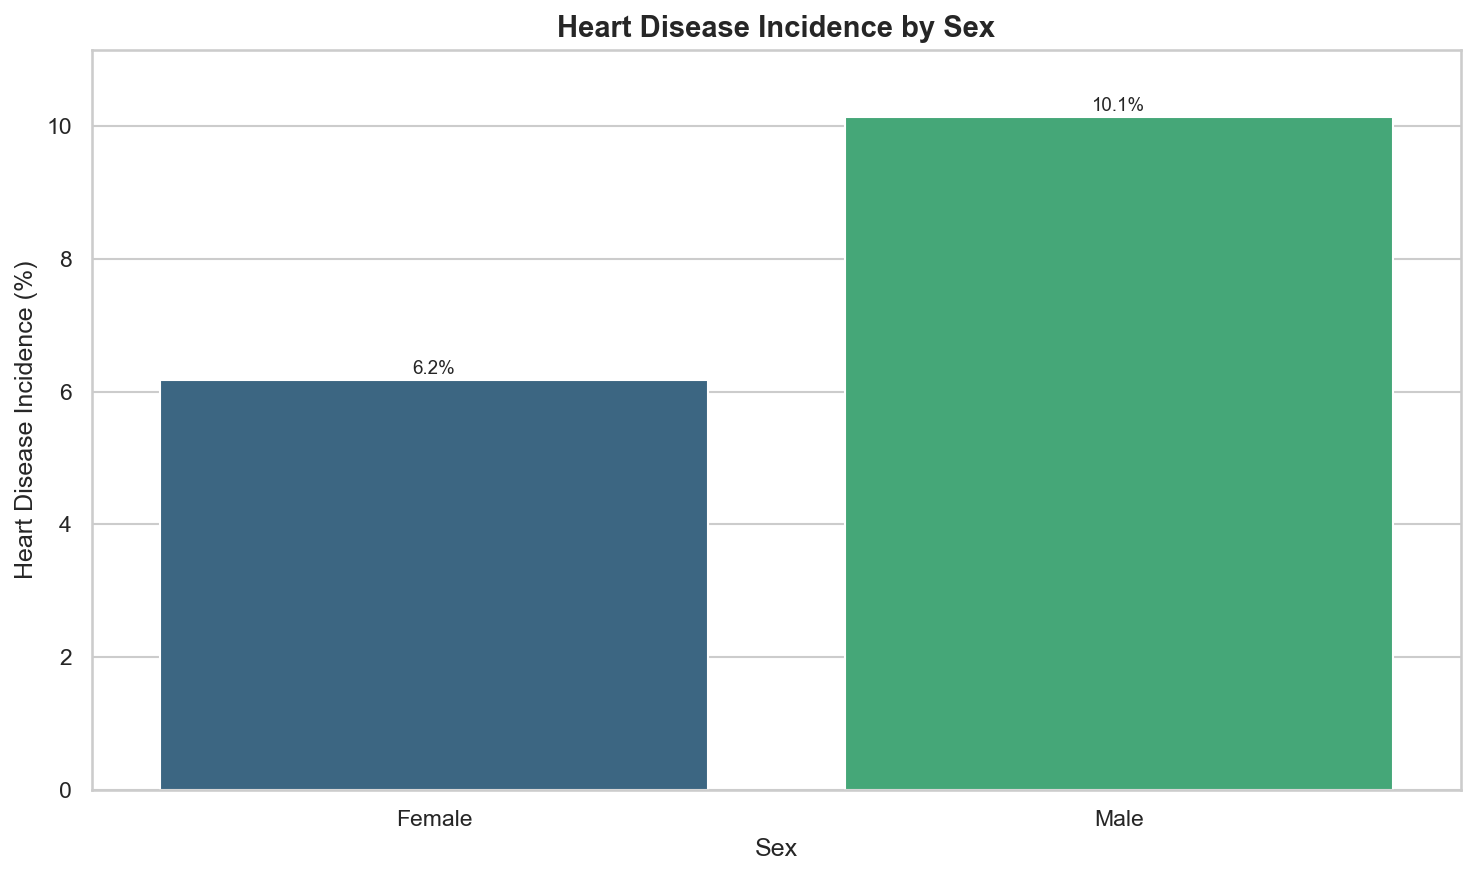


--- 6. Fried Potato Consumption Incidence ---


C:\Users\jsrri\AppData\Local\Temp\ipykernel_14652\4229508054.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


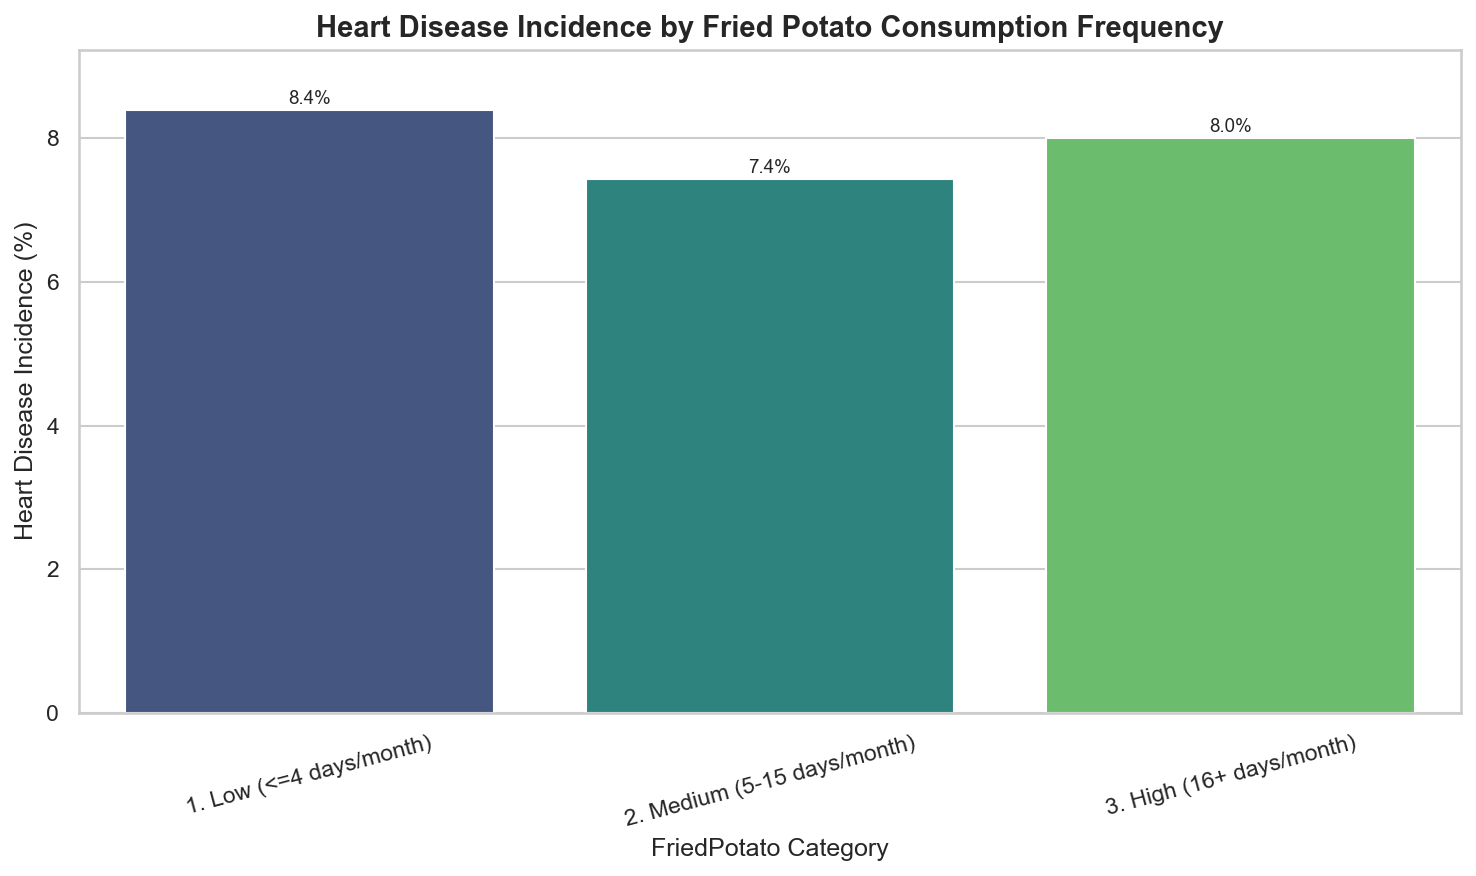


--- 7. Alcohol Consumption Incidence ---


C:\Users\jsrri\AppData\Local\Temp\ipykernel_14652\4229508054.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


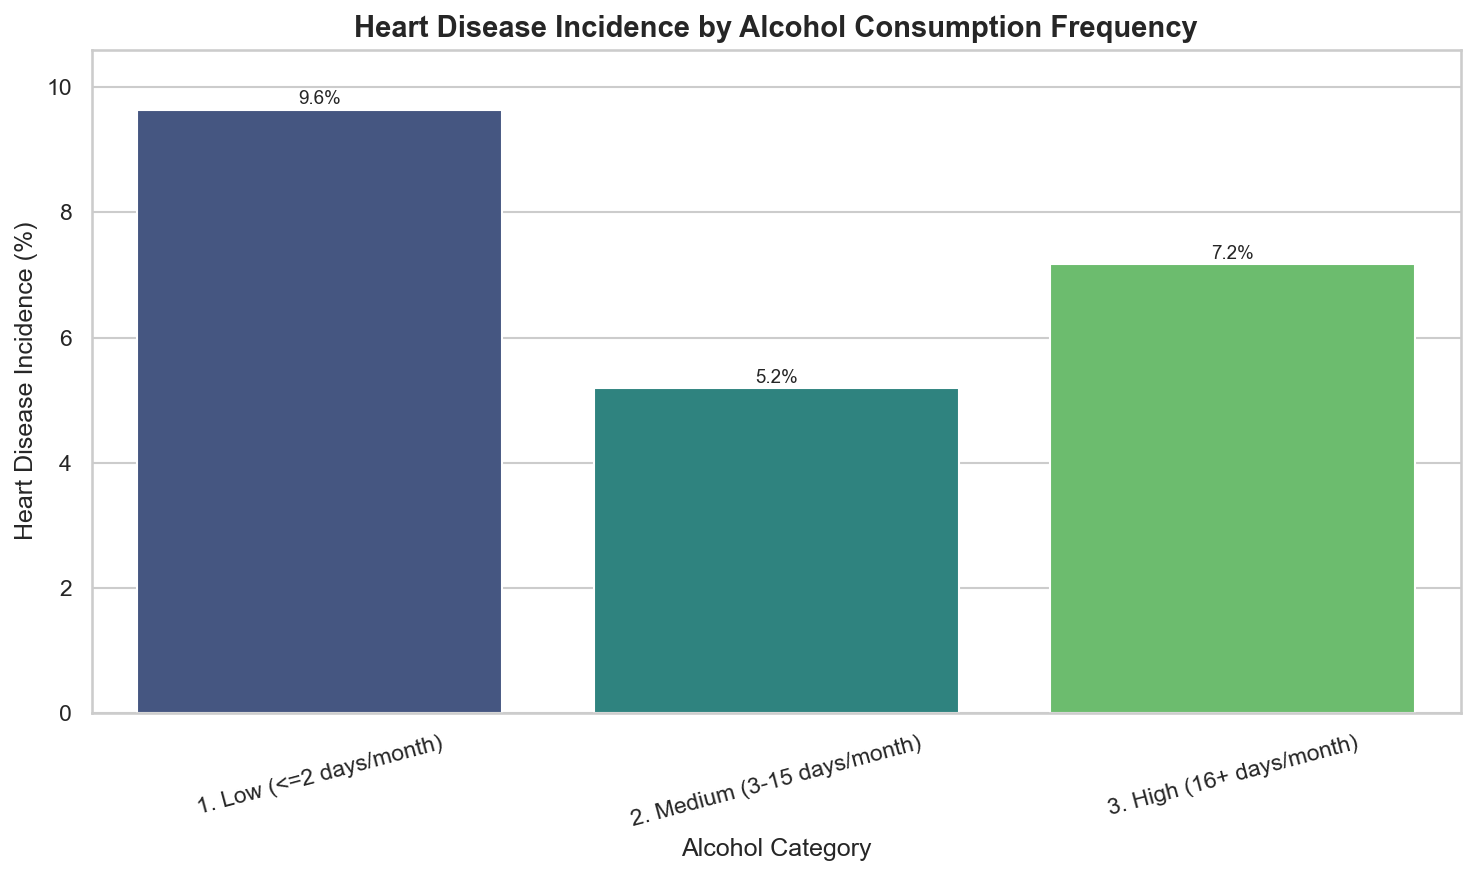


 All plots saved and displayed successfully. Check the 'eda_plots/' directory for PNG files.


In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- Configuration ---
# Set path to your cleaned data (adjust if needed)
DATA_PATH = 'data/cleaned_data.csv'
# Directory where the generated plots will be saved
PLOTS_DIR = 'eda_plots' 

# Set global style for better visualization
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = (10, 6)

def calculate_incidence_rate(df, group_col, target_col='Heart_Disease'):
    """Calculates the percentage of 'Yes' outcomes for each category."""
    
    # Convert target to numeric (1 for Yes, 0 for No)
    df_temp = df.copy()
    df_temp[target_col] = df_temp[target_col].map({'Yes': 1, 'No': 0})
    
    # Calculate mean (which is the incidence rate)
    incidence = df_temp.groupby(group_col)[target_col].mean().reset_index()
    incidence[target_col] = incidence[target_col] * 100 # Convert to percentage
    
    return incidence

def plot_incidence(data, x_col, title, filename, order=None, rotation=0, aspect=1.5):
    """Generates a bar plot, saves it to a file, and leaves the figure open for display."""
    plt.figure()
    
    ax = sns.barplot(
        x=x_col, 
        y='Heart_Disease', 
        data=data, 
        order=order,
        palette='viridis'
    )
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel('Heart Disease Incidence (%)', fontsize=12)
    plt.xlabel(x_col.replace('_', ' '), fontsize=12)
    plt.xticks(rotation=rotation)
    plt.ylim(0, max(data['Heart_Disease']) * 1.1)
    
    # Add values on top of bars
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 5), 
                    textcoords = 'offset points',
                    fontsize=9)
    
    plt.tight_layout()
    
    # Save the figure to the specified directory
    filepath = os.path.join(PLOTS_DIR, filename)
    plt.savefig(filepath)
    # plt.show() and plt.close() are called in the main block for Jupyter compatibility


def create_bmi_categories(bmi):
    """Bins BMI into standard clinical categories."""
    if bmi < 18.5:
        return '1. Underweight (<18.5)'
    elif bmi < 25:
        return '2. Normal (18.5-24.9)'
    elif bmi < 30:
        return '3. Overweight (25-29.9)'
    else:
        return '4. Obese (30+)'

def create_consumption_categories(consumption_level, feature_name):
    """Bins consumption features (days/month) into Low, Medium, High risk categories."""
    
    if feature_name == 'Alcohol_Consumption':
        # Low: 0-2 days, Medium: 3-15 days, High: 16+ days per month
        if consumption_level <= 2:
            return '1. Low (<=2 days/month)'
        elif consumption_level <= 15:
            return '2. Medium (3-15 days/month)'
        else:
            return '3. High (16+ days/month)'
    
    elif feature_name in ['Fruit_Consumption', 'Green_Vegetables_Consumption']:
        # Low consumption of beneficial foods is high risk
        if consumption_level <= 10:
            return '3. Low Consumption (<10 days/month)'
        elif consumption_level <= 20:
            return '2. Moderate Consumption (10-20 days/month)'
        else:
            return '1. High Consumption (>20 days/month)'
    
    elif feature_name == 'FriedPotato_Consumption':
        # High consumption of detrimental foods is high risk
        if consumption_level <= 4:
            return '1. Low (<=4 days/month)'
        elif consumption_level <= 15:
            return '2. Medium (5-15 days/month)'
        else:
            return '3. High (16+ days/month)'
    
    return 'Unknown'


# --- Main EDA Visualization ---
try:
    # Added path logging to help debug CWD issues
    data_abs_path = os.path.abspath(DATA_PATH)
    print(f"Attempting to load data from (Absolute Path): {data_abs_path}")
    
    df = pd.read_csv(DATA_PATH)
    print(f"Data loaded successfully from: {DATA_PATH}")

    # Create the plots directory if it doesn't exist
    os.makedirs(PLOTS_DIR, exist_ok=True)
    
    plots_abs_path = os.path.abspath(PLOTS_DIR)
    print(f"Plots will be saved to the directory (Absolute Path): {plots_abs_path}")
    
    # ---------------------------------------------
    # 1. BMI (Numerical Feature Binned)
    # ---------------------------------------------
    print("\n--- 1. BMI Incidence by Clinical Category ---")
    df['BMI_Category'] = df['BMI'].apply(create_bmi_categories)
    bmi_incidence = calculate_incidence_rate(df, 'BMI_Category')
    
    plot_incidence(
        bmi_incidence, 
        'BMI_Category', 
        'Heart Disease Incidence by BMI Category', 
        '1_bmi_incidence.png',
        order=sorted(df['BMI_Category'].unique()), 
        rotation=15
    )
    plt.show() # Force inline display
    plt.close() # Close figure after display

    # ---------------------------------------------
    # 2. Exercise (Binary Feature)
    # ---------------------------------------------
    print("\n--- 2. Exercise Incidence ---")
    exercise_incidence = calculate_incidence_rate(df, 'Exercise')
    
    plot_incidence(
        exercise_incidence, 
        'Exercise', 
        'Heart Disease Incidence: Exercise vs. No Exercise', 
        '2_exercise_incidence.png',
        order=['No', 'Yes']
    )
    plt.show()
    plt.close()

    # ---------------------------------------------
    # 3. Comorbidity Synergy (Arthritis and Depression)
    # ---------------------------------------------
    print("\n--- 3. Chronic Condition Synergy (Arthritis & Depression) ---")
    df['Chronic_Status'] = df.apply(
        lambda row: f"Arthritis: {row['Arthritis']} / Depression: {row['Depression']}", axis=1
    )
    chronic_incidence = calculate_incidence_rate(df, 'Chronic_Status')
    
    chronic_order = [
        'Arthritis: No / Depression: No',
        'Arthritis: Yes / Depression: No',
        'Arthritis: No / Depression: Yes',
        'Arthritis: Yes / Depression: Yes',
    ]
    
    plot_incidence(
        chronic_incidence, 
        'Chronic_Status', 
        'Heart Disease Incidence by Chronic Condition Synergy', 
        '3_comorbidity_synergy.png',
        order=chronic_order, 
        rotation=30
    )
    plt.show()
    plt.close()

    # ---------------------------------------------
    # 4. Checkup Status (Health Access Proxy)
    # ---------------------------------------------
    print("\n--- 4. Checkup Status Incidence ---")
    checkup_incidence = calculate_incidence_rate(df, 'Checkup')
    
    checkup_order = [
        'Within the past year', 
        'Within the past 2 years', 
        'Within the past 5 years', 
        '5 or more years ago', 
        'Never'
    ]
    
    plot_incidence(
        checkup_incidence, 
        'Checkup', 
        'Heart Disease Incidence by Time Since Last Checkup', 
        '4_checkup_status.png',
        order=checkup_order, 
        rotation=45
    )
    plt.show()
    plt.close()
    
    # ---------------------------------------------
    # 5. Sex (Demographic Feature)
    # ---------------------------------------------
    print("\n--- 5. Sex Incidence ---")
    sex_incidence = calculate_incidence_rate(df, 'Sex')
    
    plot_incidence(
        sex_incidence, 
        'Sex', 
        'Heart Disease Incidence by Sex', 
        '5_sex_incidence.png',
        order=['Female', 'Male']
    )
    plt.show()
    plt.close()
    
    # ---------------------------------------------
    # 6. Lifestyle Risk (Fried Potatoes Consumption)
    # ---------------------------------------------
    print("\n--- 6. Fried Potato Consumption Incidence ---")
    df['FriedPotato_Category'] = df['FriedPotato_Consumption'].apply(
        lambda x: create_consumption_categories(x, 'FriedPotato_Consumption')
    )
    fried_potato_incidence = calculate_incidence_rate(df, 'FriedPotato_Category')
    
    plot_incidence(
        fried_potato_incidence, 
        'FriedPotato_Category', 
        'Heart Disease Incidence by Fried Potato Consumption Frequency', 
        '6_friedpotato_consumption.png',
        order=sorted(df['FriedPotato_Category'].unique()),
        rotation=15
    )
    plt.show()
    plt.close()

    # ---------------------------------------------
    # 7. Lifestyle Risk (Alcohol Consumption)
    # ---------------------------------------------
    print("\n--- 7. Alcohol Consumption Incidence ---")
    df['Alcohol_Category'] = df['Alcohol_Consumption'].apply(
        lambda x: create_consumption_categories(x, 'Alcohol_Consumption')
    )
    alcohol_incidence = calculate_incidence_rate(df, 'Alcohol_Category')
    
    plot_incidence(
        alcohol_incidence, 
        'Alcohol_Category', 
        'Heart Disease Incidence by Alcohol Consumption Frequency', 
        '7_alcohol_consumption.png',
        order=sorted(df['Alcohol_Category'].unique()),
        rotation=15
    )
    plt.show()
    plt.close()
    
    print(f"\n All plots saved and displayed successfully. Check the '{PLOTS_DIR}/' directory for PNG files.")

except FileNotFoundError:
    print(f"\nError: Data file not found at {DATA_PATH}. Please check your path.")
    print(f"Absolute path checked: {data_abs_path}")
except Exception as e:
    print(f"\nAn unexpected error occurred during plotting: {e}")
